In [11]:
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [12]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [14]:
data_dir = "/kaggle/input/datasets/veeraiahkondra/venkat-kondra/Final_Data"  # change this



In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

In [16]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [17]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [18]:
class MHSA(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.qkv = nn.Conv2d(dim, dim*3, kernel_size=1)
        self.proj = nn.Conv2d(dim, dim, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(x).reshape(B, 3, self.num_heads, C//self.num_heads, H*W)
        q, k, v = qkv[:,0], qkv[:,1], qkv[:,2]

        attn = torch.softmax((q @ k.transpose(-2,-1)) / np.sqrt(C), dim=-1)
        out = (attn @ v).reshape(B, C, H, W)

        return self.proj(out)

In [19]:
!pip install timm
import timm
model = timm.create_model(
    'convit_base',   # hybrid transformer
    pretrained=True,
    num_classes=len(class_names)   # ✅ IMPORTANT
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [20]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [21]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_labels, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_convit.pth")

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val F1: {val_f1:.4f}")

    model.load_state_dict(torch.load("best_convit.pth"))
    return model

In [22]:
model = train_model(model, train_loader, val_loader, epochs=30)

Epoch 1 | Train Acc: 0.7057 | Val F1: 0.7957
Epoch 2 | Train Acc: 0.8019 | Val F1: 0.8187
Epoch 3 | Train Acc: 0.8234 | Val F1: 0.7491
Epoch 4 | Train Acc: 0.8364 | Val F1: 0.8382
Epoch 5 | Train Acc: 0.8374 | Val F1: 0.8613
Epoch 6 | Train Acc: 0.8563 | Val F1: 0.8584
Epoch 7 | Train Acc: 0.8532 | Val F1: 0.8614
Epoch 8 | Train Acc: 0.8572 | Val F1: 0.8244
Epoch 9 | Train Acc: 0.8964 | Val F1: 0.8940
Epoch 10 | Train Acc: 0.9055 | Val F1: 0.9038
Epoch 11 | Train Acc: 0.9180 | Val F1: 0.8983
Epoch 12 | Train Acc: 0.9218 | Val F1: 0.9029
Epoch 13 | Train Acc: 0.9273 | Val F1: 0.8880
Epoch 14 | Train Acc: 0.9481 | Val F1: 0.9104
Epoch 15 | Train Acc: 0.9557 | Val F1: 0.9134
Epoch 16 | Train Acc: 0.9601 | Val F1: 0.9154
Epoch 17 | Train Acc: 0.9648 | Val F1: 0.9155
Epoch 18 | Train Acc: 0.9706 | Val F1: 0.9070
Epoch 19 | Train Acc: 0.9723 | Val F1: 0.9133
Epoch 20 | Train Acc: 0.9811 | Val F1: 0.9133
Epoch 21 | Train Acc: 0.9830 | Val F1: 0.9127
Epoch 22 | Train Acc: 0.9836 | Val F1: 0.91

In [23]:
for param in model.parameters():
    param.requires_grad = True

In [24]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      1.00       405
             Normal       0.98      0.98      0.98       405
Pneumonia-Bacterial       0.85      0.87      0.86       405
    Pneumonia-Viral       0.87      0.84      0.85       405

           accuracy                           0.92      1620
          macro avg       0.92      0.92      0.92      1620
       weighted avg       0.92      0.92      0.92      1620



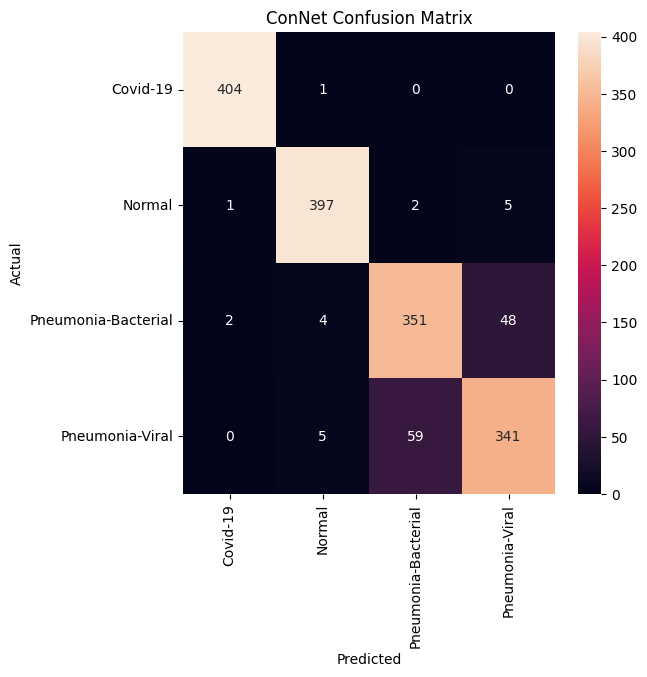

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ConNet Confusion Matrix")
plt.show()

In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [27]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

print("Probs:", all_probs.shape)
print("Labels:", all_labels.shape)

Probs: (1620, 4)
Labels: (1620,)


In [28]:
num_classes = all_probs.shape[1]

all_labels_bin = label_binarize(
    all_labels,
    classes=list(range(num_classes))
)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

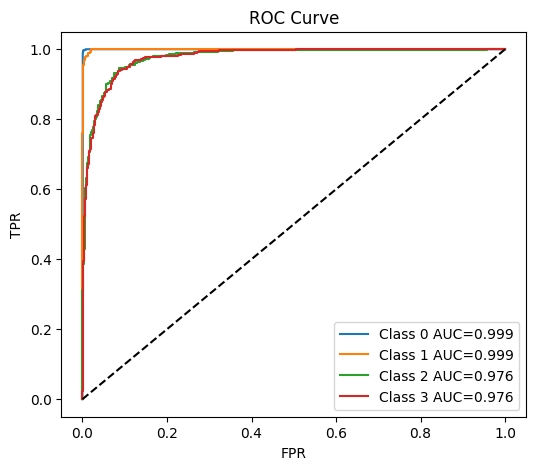

In [29]:
plt.figure(figsize=(6,5))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC={roc_auc[i]:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [30]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        output = self.model(x)
        self.model.zero_grad()

        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1,2))

        cam = torch.zeros(activations.shape[1:], device=x.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= cam.max()

        return cam.detach().cpu().numpy()

In [31]:
# Try one of these (depends on your model)
target_layer = model.layer4[-1]   # MOST COMMON
# or
# target_layer = model.conv5

AttributeError: 'ConVit' object has no attribute 'layer4'

In [32]:
grad_cam = GradCAM(model, target_layer)

images, labels = next(iter(test_loader))

img = images[0:1].to(device)
label = labels[0].item()

cam = grad_cam.generate(img, label)

NameError: name 'target_layer' is not defined

In [33]:
import cv2
import matplotlib.pyplot as plt

img_np = img.squeeze().permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

heatmap = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

overlay = heatmap * 0.4 + img_np * 255

plt.imshow(overlay.astype(np.uint8))
plt.title("Grad-CAM (BoTNet)")
plt.axis('off')
plt.show()

NameError: name 'img' is not defined

In [34]:
class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N=300, s=8, p1=0.5):
        masks = []
        for _ in range(N):
            mask = (np.random.rand(s, s) < p1).astype(np.float32)
            mask = cv2.resize(mask, self.input_size)
            masks.append(mask)
        return np.array(masks)

    def explain(self, image, masks):
        preds = []

        for mask in masks:
            mask_tensor = torch.tensor(mask).to(self.device)
            masked = image * mask_tensor
            masked = masked.unsqueeze(0)

            with torch.no_grad():
                pred = torch.softmax(self.model(masked), dim=1)

            preds.append(pred.cpu().numpy())

        preds = np.concatenate(preds)

        saliency = np.zeros(self.input_size)

        for i in range(len(masks)):
            saliency += preds[i].max() * masks[i]

        saliency /= len(masks)

        return saliency

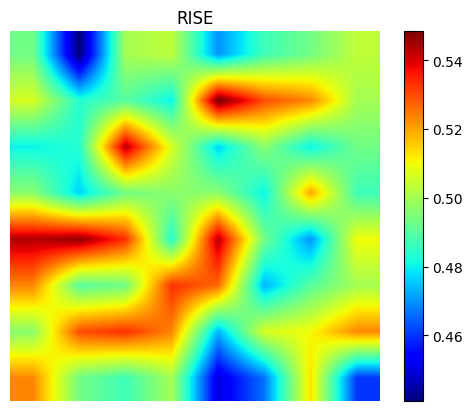

In [35]:
rise = RISE(model, (224,224), device)

images, labels = next(iter(test_loader))
img = images[0].to(device)

masks = rise.generate_masks()
saliency = rise.explain(img, masks)

plt.imshow(saliency, cmap='jet')
plt.colorbar()
plt.title("RISE")
plt.axis('off')
plt.show()